#🚦# Smart Traffic Alert Text Classification
**Dataset:** DSTI Traffic Accident Reports 800 (Hugging Face)  
**Task:** Multi-class text classification  
**Goal:** Automatically classify traffic accident reports for smart traffic system alerts.

#Import Libraries

In [ ]:
!pip install datasets scikit-learn pandas numpy matplotlib seaborn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re


#Load Dataset
Loads the dataset from Hugging Face

In [ ]:
dataset = load_dataset("DSTI/traffic-accidents-reports-800")
df = dataset["train"].to_pandas()
df.head()

,input,target
0,"What: rear-end collision, 2 vehicles\nWhen: Oc...","On July 6, 2024, at 21:55, a rear-end collisio..."
1,What: Sideswipe incident between Vehicle A (ca...,"On July 2, 2024, at 18:15, Vehicle A (car) dri..."
2,"What: Car lost control, collided with van in w...","On July 3, 2024, at 8:40 p.m., Vehicle A, a co..."
3,What: T-bone collision at intersection\nWhen: ...,"On May 18, 2024, at 21:10, Mr. Leo Kim (Vehicl..."
4,What: single-vehicle rollover involving car (A...,"On March 12, 2024, at 23:45, Ms. Petra Lee los..."


#Extract Category and Create Binary Labels

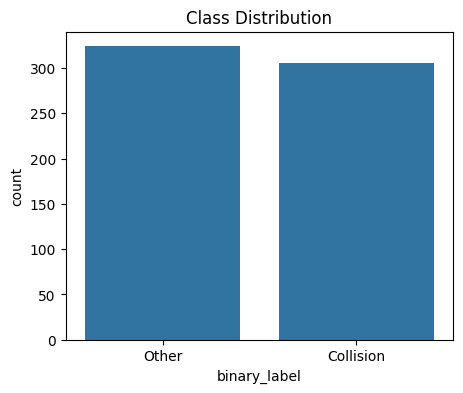

In [ ]:
def extract_category(text):
    try:
        return text.split("What:")[1].split("\n")[0].strip().lower()
    except:
        return "unknown"

df['category'] = df['input'].apply(extract_category)

# Binary label: 1 = collision, 0 = other
df['binary_label'] = df['category'].apply(lambda x: 1 if 'collision' in x else 0)

# Plot class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='binary_label', data=df)
plt.xticks([0,1], ['Other','Collision'])
plt.title("Class Distribution")
plt.show()


#Check Dataset Info

see structure, nulls, and class counts.

In [ ]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   input         629 non-null    object
 1   target        629 non-null    object
 2   category      629 non-null    object
 3   binary_label  629 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 19.8+ KB
None
                                               input  \
0  What: rear-end collision, 2 vehicles\nWhen: Oc...   
1  What: Sideswipe incident between Vehicle A (ca...   
2  What: Car lost control, collided with van in w...   
3  What: T-bone collision at intersection\nWhen: ...   
4  What: single-vehicle rollover involving car (A...   

                                              target  \
0  On July 6, 2024, at 21:55, a rear-end collisio...   
1  On July 2, 2024, at 18:15, Vehicle A (car) dri...   
2  On July 3, 2024, at 8:40 p.m., Vehicle A, a co...   
3  On May 18, 2024, at 21:1

#Clean Text

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['clean_input'] = df['input'].apply(clean_text)


#Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_input'], df['binary_label'],
    test_size=0.2, random_state=42, stratify=df['binary_label']
)


#TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Train Naive Bayes Model

In [ ]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

#Evaluate Model

Test Accuracy: 0.7380952380952381
              precision    recall  f1-score   support

       Other       0.75      0.74      0.74        65
   Collision       0.73      0.74      0.73        61

    accuracy                           0.74       126
   macro avg       0.74      0.74      0.74       126
weighted avg       0.74      0.74      0.74       126



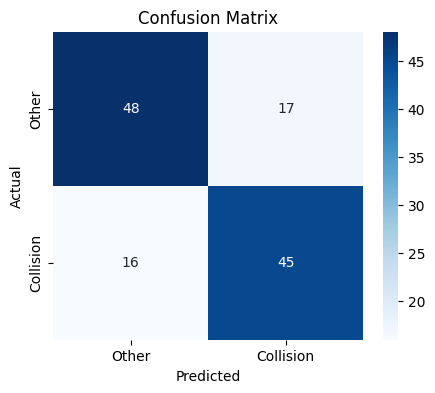

In [ ]:
y_pred = model.predict(X_test_tfidf)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Classification report
print(classification_report(y_test, y_pred, target_names=['Other','Collision']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=['Other','Collision'], yticklabels=['Other','Collision'], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#Top Predictive Words

In [ ]:
import numpy as np

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Get log probabilities from the trained Naive Bayes model
# class 0 = Other, class 1 = Collision
log_probs = model.feature_log_prob_

top_n = 10

# Top words for Collision
top_collision_idx = np.argsort(log_probs[1])[::-1][:top_n]
top_collision_words = feature_names[top_collision_idx]
top_collision_scores = log_probs[1][top_collision_idx]

# Top words for Other
top_other_idx = np.argsort(log_probs[0])[::-1][:top_n]
top_other_words = feature_names[top_other_idx]
top_other_scores = log_probs[0][top_other_idx]

# Display as DataFrames
df_collision = pd.DataFrame({'Word': top_collision_words, 'Log Prob': top_collision_scores})
df_other = pd.DataFrame({'Word': top_other_words, 'Log Prob': top_other_scores})

print("Top Words for Collision:")
display(df_collision)

print("Top Words for Other:")
display(df_other)


Top Words for Collision:


,Word,Log Prob
0,vehicle,-5.589632
1,and,-6.414057
2,collision,-6.427563
3,driver,-6.444363
4,driver vehicle,-6.632761
5,to,-6.677292
6,car,-6.726030
7,sedan,-6.732593
8,mr,-6.787049
9,intersection,-6.793941


Top Words for Other:


,Word,Log Prob
0,vehicle,-5.679531
1,driver,-6.432577
2,car,-6.522601
3,truck,-6.542356
4,pedestrian,-6.637176
5,to,-6.708095
6,road,-6.772583
7,mr,-6.776766
8,and,-6.798142
9,when,-6.867515


#Plot Top Words

/tmp/ipython-input-1890346251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Log Prob', y='Word', data=df_collision, palette='Reds')
/tmp/ipython-input-1890346251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Log Prob', y='Word', data=df_other, palette='Blues')


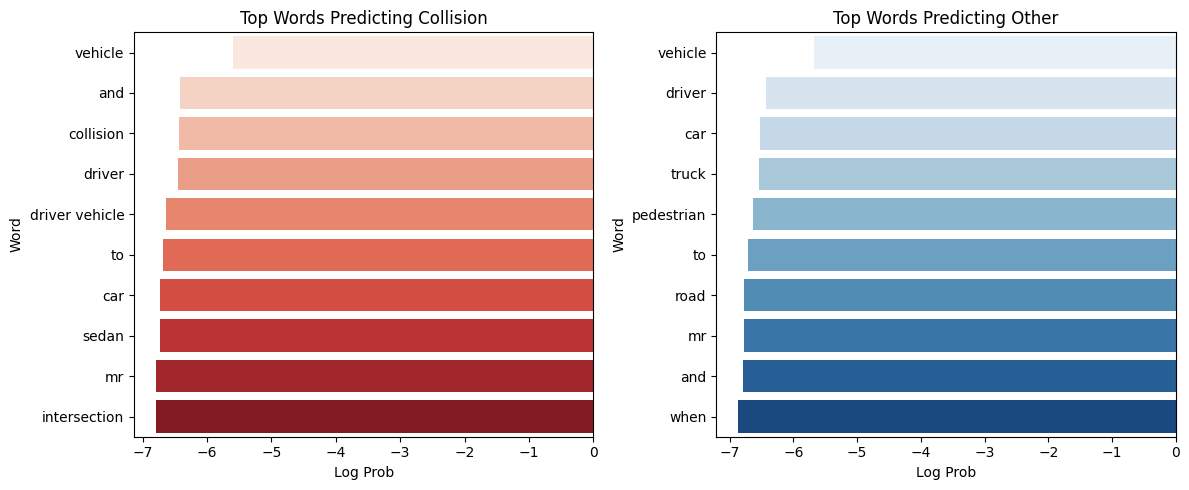

In [ ]:
plt.figure(figsize=(12,5))

# Collision words
plt.subplot(1,2,1)
sns.barplot(x='Log Prob', y='Word', data=df_collision, palette='Reds')
plt.title("Top Words Predicting Collision")

# Other words
plt.subplot(1,2,2)
sns.barplot(x='Log Prob', y='Word', data=df_other, palette='Blues')
plt.title("Top Words Predicting Other")

plt.tight_layout()
plt.show()
